# PNR Ardennes

# 0. Configuration

In [ ]:
# !pip install osmnx
# !pip install scikit-image
# !pip install seaborn

# import sys
# custom_dir = '/home/jovyan/work/team/marion/corridor_project/libs'
# %pip install smoothify --no-deps --target={custom_dir} --no-cache-dir
# # %pip install ipyvuetify leafmap --target={custom_dir} --no-cache-dir  # removed: Dash app deleted

In [25]:
import os
import sys
import numpy as np
import geopandas as gpd
import ee
import matplotlib.pyplot as plt
import networkx as nx

# personal modules
sys.path.insert(1, '../../marion/corridor_project/utils/')
import landcover as lc
import connectivity as conn
import routing as rout
import vizu_ind as viz
import sp_pipeline
sys.path.insert(1, '../../marion/corridor_project/utils/')
import species_params as spp

# Authentification GEE
service_account = 'gee-141@gee161025.iam.gserviceaccount.com'
credentials_path = '../../marion/credentials/gee161025-533af22f806b.json'
credentials = ee.ServiceAccountCredentials(service_account, credentials_path)
ee.Initialize(credentials)

# case study def
CITY = "Ardennes"
ECOPROFIL_KEY = "ground_mammal"
specie = spp.SPECIES_CONFIG[ECOPROFIL_KEY]
from paths import CorridorPaths; OUTPUT_DIR = str(CorridorPaths(CITY).city_dir)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Paramètres AOI
sys.path.insert(1, '../../Hugo/a_b_c_functions/')
from spatial_analysis.utils_vector import gdf_to_bbox
from OSM.get_boundary import get_boundary
aoi_raw = get_boundary('Parc naturel régional des Ardennes')
aoi_raw.to_file(f"{OUTPUT_DIR}/aoi_limits_{CITY}.geojson", driver='GeoJSON')

In [2]:
import importlib
import landcover as lc
import connectivity as conn
import routing as rout
import vizu_ind as viz
import sp_pipeline
import species_params as spp
importlib.reload(lc)
importlib.reload(conn)
importlib.reload(rout)
importlib.reload(viz)
importlib.reload(sp_pipeline)
importlib.reload(spp)

<module 'species_params' from '/home/jovyan/work/team/marion/corridor_project/../../marion/corridor_project/utils/species_params.py'>

In [3]:
# display(spp.get_summary_df())
# df = spp.prepare_data(specie.SPECIES_CONFIG)
# spp.plot_friction_by_ecoprofil(df)
# spp.plot_friction_by_landcover(df)
print(spp.get_summary_df().to_string(index=False))
display(spp.get_summary_df())

              clé                                 profil écologique  chimère  d0 (m)  threshold (UC)              habitat        barrières           réf. CEREMA  n. espèces rep.                                                                                                                                                                             réfs
    ground_mammal         Mammifère terrestre de lisière    False    3000            9000         [10, 20, 30]     [80, 51, 52]     Hérisson d'Europe                4             Frictions : CEREMA La Rochelle (2025) pp. 96-98 col. Hérisson. Distance d0 : Tab. 8 p44 (cortège Mixte). Cadre profil écologique : approche propre (cette étude).
  arboreal_mammal        Mammifère arboricole de canopée    False    2000            6000                 [10]         [52, 51]         Écureuil roux                4 Frictions : CEREMA La Rochelle (2025) pp. 96-98 col. Écureuil. Distance d0 : Tab. 8 p44 (cortège Arborée/Arbustive). Cadre profil écologi

,clé,profil écologique,chimère,d0 (m),threshold (UC),habitat,barrières,réf. CEREMA,n. espèces rep.,réfs
0,ground_mammal,Mammifère terrestre de lisière,False,3000,9000,"[10, 20, 30]","[80, 51, 52]",Hérisson d'Europe,4,Frictions : CEREMA La Rochelle (2025) pp. 96-9...
1,arboreal_mammal,Mammifère arboricole de canopée,False,2000,6000,[10],"[52, 51]",Écureuil roux,4,Frictions : CEREMA La Rochelle (2025) pp. 96-9...
2,forest_edge_bird,Oiseau de mosaïque boisée,False,1500,4500,"[10, 20]",[],Fauvette à tête noire,4,Frictions : CEREMA La Rochelle (2025) pp. 96-9...
3,ground_reptile,Reptile thermophile de milieux ouverts,False,750,2250,"[20, 30, 60]","[80, 51, 52, 53]",Lézard des murailles,4,Frictions : CEREMA La Rochelle (2025) pp. 96-9...
4,herbaceous_insect,Insecte des milieux herbacés ouverts,False,300,900,"[20, 30, 60, 90, 95]",[51],Criquet duettiste,5,Frictions : CEREMA La Rochelle (2025) pp. 96-9...


In [4]:
max_d0 = max(specie['graph']['d0'] for specie in spp.SPECIES_CONFIG.values())
aoi_utm, aoi_ee, utm_epsg = lc.setup_aoi(aoi_raw)
total_area_km2 = aoi_utm.area.sum() / 1e6
print(total_area_km2)

master_buffered_geom = gpd.GeoSeries(aoi_utm.buffer(2 * max_d0), crs=utm_epsg).to_crs(aoi_raw.crs)
master_aoi_buffered = aoi_raw.copy()
master_aoi_buffered.geometry = master_buffered_geom
master_aoi_buffered = master_aoi_buffered.dissolve()

master_aoib_utm, master_aoib_ee, master_utmb_epsg = lc.setup_aoi(master_aoi_buffered)
master_areab_km2 = master_aoib_utm.area.sum() / 1e6
print(master_areab_km2)

lc_wc, lc_osm = lc.download_lc_data(master_aoib_ee, master_aoib_utm, master_aoi_buffered, master_utmb_epsg)

1182.8720433218084
2495.9720539169207


/opt/conda/lib/python3.11/site-packages/xee/ext.py:685: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(


# 1. Landcover

Landcover raster combining ESA WorldCover and OSM

In [5]:
da_lc = lc.generate_ecoprofil_landcover(lc_wc, lc_osm, master_aoi_buffered, master_utmb_epsg, specie['habitat_codes'])
print(f"Valeurs : {np.unique(da_lc.values)}")

# da_export = da_lc.fillna(0).astype('uint8')
# da_export.rio.to_raster(f"{OUTPUT_DIR}/landcover_{CITY}.tif")

Valeurs : [10. 20. 30. 40. 50. 51. 52. 53. 54. 55. 60. 80. 90. nan]


# 2. Habitat Morphology - MSPA

Identifies morphological connectivity elements (nodes and stepping stones) based on species preferences

In [6]:
binary_wc = conn.get_binary_habitat(da_lc, specie['habitat_codes'])

gdf_cores, gdf_islets = conn.get_connectivity_elements(binary_wc, core_min_ha=1.0, islet_min_ha=0.1)
gdf_islets = gdf_islets[gdf_islets['class'] == "Stepping Stone (Small Core)"].copy()
print(f"✓ {len(gdf_cores)} Noyaux de biodiversité et {len(gdf_islets)} Stepping Stones (Small Cores) identifiés.")

# binary_wc.rio.to_raster(f"{OUTPUT_DIR}/binary_habitat_{CITY}.tif")

✓ 2716 Noyaux de biodiversité et 5701 Stepping Stones (Small Cores) identifiés.


# 3. Graph Connectivity Analysis

## 3.1. Network modeling

The landscape is modeled as a graph where Nodes represent habitat patches and Edges represent potential dispersal links.
- Probabilistic approach: Connection strength is based on an exponential decay function relative to the species dispersal distance ($d_0$) - probability of movement between patches.
  > what i tried: K-nearest neighbors graph (feels forced, too little or too far, no distance involved), Relative neighborhood graph (too restrictive, no loops), Gabriel graph (capture local neighborhood, redundancy allowed)

  
- Gabriel graph is the approach adopted, seems to be the better trade-off
     - **Step 1**: To be quicker, it doesn't check every habitat against every other one but it looks at a patch and search for other patches at ($2 \times d0$) of it. It calculates the Edge-to-Edge distance (instead of centroid-to-centroid).
     - **Step 2**: The Gabriel Filter (= shortcuts rule), it draws an imaginary circle where the path between A and B is the diameter. If there is another Habitat C inside that circle, the path between A and B is deleted.
     - **Step 3**: If a path survives the filter, it calculates how likely it is to actually make the trip:
        1. Probability ($prob$): It uses an exponential decay, the further the distance, the lower the chance of movement.
        2. Cost: It converts that probability into a "cost" (logarithm), to find the shortest/safest path. 

In [7]:
df_nodes = conn.prepare_graph_nodes(gdf_cores, gdf_islets)
# G_knn = conn.build_connectivity_graph_knn(df_nodes, specie)
# G_rng = conn.build_rng_graph(df_nodes, specie)
G = conn.build_gabriel_graph(df_nodes, specie)

Step 2/2: Gabriel filtering: 100%|██████████| 49560/49560 [00:05<00:00, 9097.98it/s]

Gabriel graph built: 8417 nodes and 16645 edges.


In [8]:
sys.path.insert(1, '../../Hugo/a_b_c_functions/spatial_analysis/')
# safe_smooth now comes from routing (rout.safe_smooth) - index-stable, geoai-free
df_nodes = rout.safe_smooth(df_nodes)
df_nodes["geometry"] = df_nodes.geometry.buffer(0)

## 3.2. Theoretical PC index

Probability of Connectivity (PC) Index measures landscape permeability for a given functional ecoprofil. It represents the probability that 2 points randomly placed in the city fall within connected habitat patches.
> Remark: Now that we use edge-to-edge instead of centroids, the internal distance is not taken into account, this can overestimates connectivity beacuse it ignores the space occupied by the patch itself  
> Assumption: movement inside patches is free  

In [9]:
# G (buffer), total_area_km2 (strict)
pc_value = conn.calculate_pc_index(G, total_area_km2)
print(f"Indice PC pour {CITY} : {pc_value:.3f}")

gdf_edges = conn.graph_to_gdf_edges(G, master_utmb_epsg)
# gdf_edges.to_file(f"{OUTPUT_DIR}/edges_{CITY}.json", driver='GeoJSON')

Indice PC pour PNR Ardennes : 0.040


# 4. Least Cost Path Analysis

From euclidean distance to real-world distance that accounts for landscape friction. Simulation of the optimal path for a given species between each node.

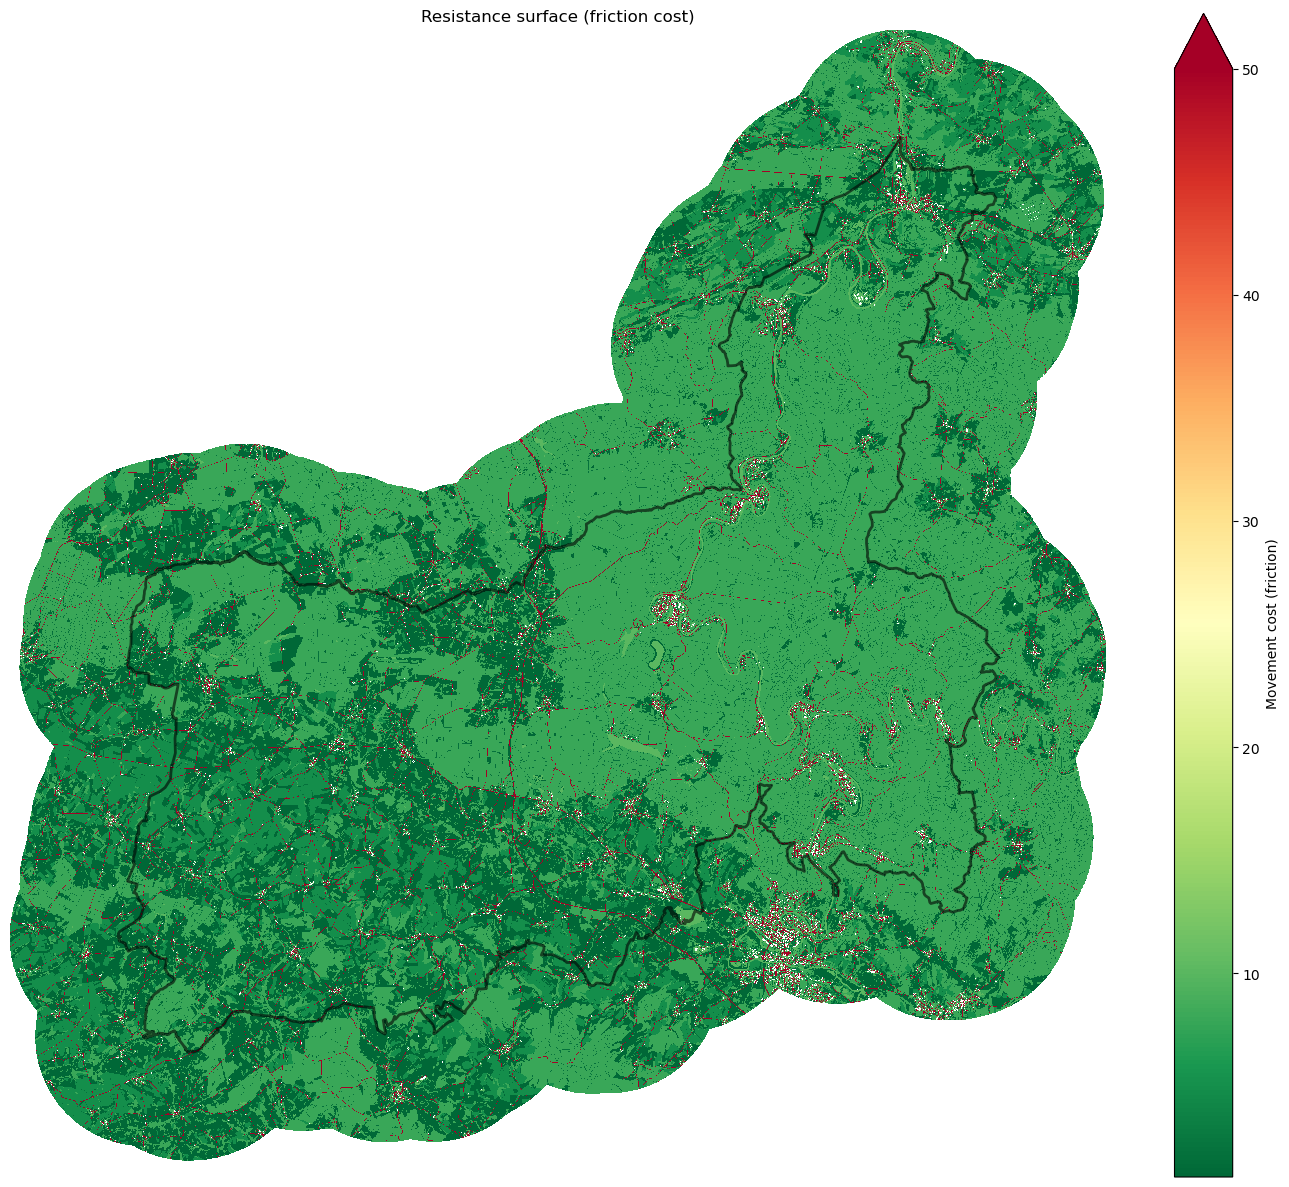

In [10]:
# raster de friction
resistance_raster = rout.create_resistance_surface(da_lc, specie['friction'])
viz.plot_resistance_surface(resistance_raster, aoi_utm)
# resistance_raster.rio.to_raster(f"{OUTPUT_DIR}/friction_{CITY}.tif")

In [11]:
# en unité coût
# d0 (en mètres) et friction avg comparé à accumulated cost (en UC: somme friction x distance pixel), paramètre sampling manquant corrigé (erreur où 1 pixel = 1 mètre, maintenant 10 mètres)

d0 = specie['graph']['d0']
threshold = d0 * spp.FRICTION_AVG_FAVORABLE
gdf_lcp = rout.compute_lcp_network(gdf_edges, df_nodes, da_lc, specie['friction'], max_cost_threshold=threshold)

Tracing LCPs: 100%|██████████| 16645/16645 [14:51<00:00, 18.67it/s]

Done: 10564 success, 6081 failed.
fail_reason
cost_threshold_exceeded    6081
Name: count, dtype: int64


In [ ]:
# gdf_lcp_success = gdf_lcp[gdf_lcp['status'] == 'success']
# print((gdf_lcp_success['accumulated_cost'] / gdf_lcp_success['real_dist']).describe())

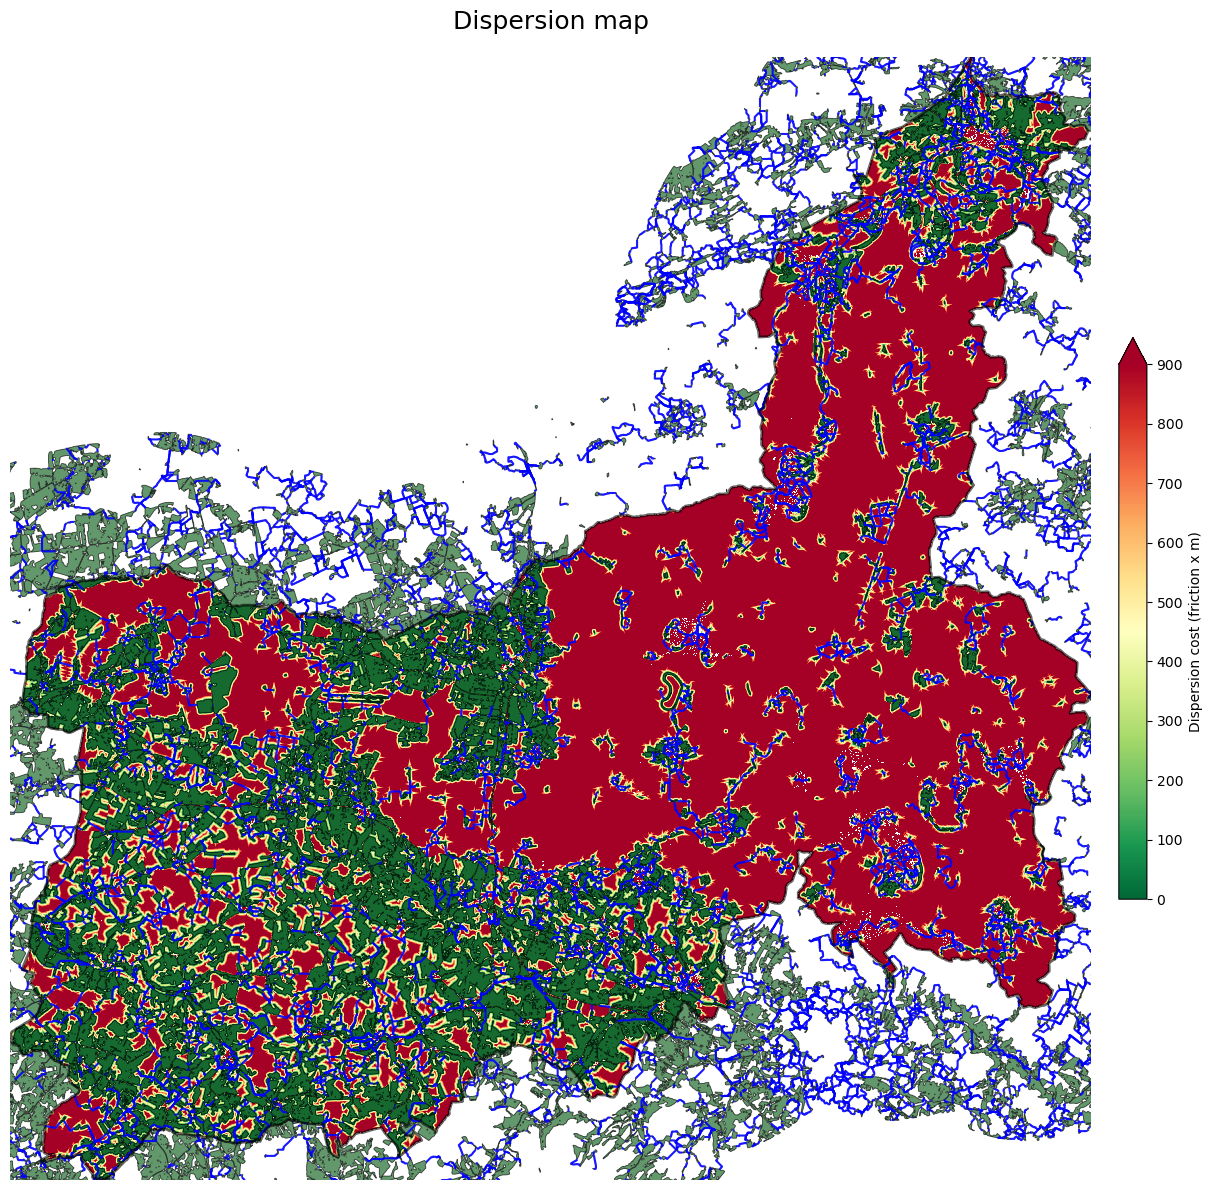

In [12]:
## DISPERSAL MAP

disp = rout.compute_dispersal_surface(da_lc, df_nodes, specie['friction'])
disp_city = disp.rio.clip(aoi_utm.geometry, aoi_utm.crs, drop=True)
dispersal_raster = disp_city.where(np.isfinite(disp_city))   # drop inf (unreachable) so it renders transparent
viz.plot_dispersal_surface(disp_city, aoi_utm, df_nodes, threshold, gdf_lcp) 
dispersal_raster.rio.to_raster(f"{OUTPUT_DIR}/dispersal_{CITY}.tif")

# vals = disp.values[np.isfinite(disp.values)]
# threshold = float(np.percentile(vals, 99))   # ≈ 3547
# plot_dispersal_surface(disp_city, aoi_utm, df_nodes, threshold=threshold)

## 4.1. Identification des zones de ruptures

In [13]:
gdf_lcp_city = gdf_lcp[gdf_lcp.geometry.intersects(aoi_utm.union_all())].copy() # on coupe le buffer

In [14]:
gdf_ruptures = conn.extract_rupture_points(gdf_lcp=gdf_lcp_city, lc_osm=lc_osm, friction_dict=specie['friction'])
gdf_failed = gdf_lcp[(gdf_lcp['status'] == 'failed') & (gdf_lcp['fail_reason'] == 'uncrossable_barrier')]

In [15]:
print(f"Total des lignes en échec (barrière) : {len(gdf_failed)}")
print(f"Total des points de rupture trouvés : {len(gdf_ruptures)}")
if not gdf_ruptures.empty:
    print(f"Colonnes disponibles : {gdf_ruptures.columns.tolist()}")

Total des lignes en échec (barrière) : 0
Total des points de rupture trouvés : 0


In [16]:
import folium

m = df_nodes.explore(
    color="lightgreen", 
    name="Habitats (Nœuds)"
)

gdf_failed.explore(
        m=m,
        color='red',
        style_kwds={'dashArray': '5, 5'},
        name="Corrdiors Échecs"
    )

if not gdf_ruptures.empty:
    gdf_ruptures.explore(
        m=m,
        color='red', 
        marker_kwds=dict(radius=6, fill=True), 
        tooltip=['wc_code', 'pn_id'],
        name="Points de Rupture"
    )

folium.LayerControl().add_to(m)
m

/tmp/ipykernel_394671/210122991.py:8: UserWarning: The GeoSeries you are attempting to plot is composed of empty geometries. Nothing has been displayed.
  gdf_failed.explore(


KeyboardInterrupt: 

In [ ]:
# viz.plot_connectivity_ruptures(gdf_lcp_city, aoi_utm, df_nodes)

## 4.2. Network metrics: median tortuosity, PC

By comparing the Theoretical PC (Euclidean from Graph) with the Real PC (LCP), we quantify the connectivity loss. This delta quantifies the impact of human infrastructure and urban matrix on species mobility.

In [17]:
gdf_lcp_city['tortuosity'] = gdf_lcp_city['real_dist'] / gdf_lcp_city['theoretical_dist']
print(f"Average Tortuosity for {CITY}: {gdf_lcp_city['tortuosity'].mean():.3f}")
print(f"Median Tortuosity for {CITY}: {gdf_lcp_city['tortuosity'].median():.3f}")

Average Tortuosity for PNR Ardennes: 2.180
Median Tortuosity for PNR Ardennes: 1.454


In [18]:
# G (buffer et success), gdf_lcp (buffer), total_area_km2 (strict)
G_pc = nx.from_pandas_edgelist(gdf_lcp, 'node_1', 'node_2')
G_pc.add_nodes_from(G.nodes(data=True))   # include distance-isolated patches (self-term aᵢ²/A²) -> denominator independent of 2·d0
for node in G_pc.nodes():
    if node in G:
        G_pc.nodes[node].update(G.nodes[node])

pc_real, G_lcp = conn.calculate_pc_index_lcp(G_pc, total_area_km2, specie, gdf_lcp)
print(f"Theoretical PC (euclidian) : {pc_value:.3f}")
print(f"Real PC (LCP) : {pc_real:.3f}")
print(f"Fragmentation impact : {((pc_value - pc_real) / pc_value)*100:.1f}% connectivity loss.")

Theoretical PC (euclidian) : 0.040
Real PC (LCP) : 0.001
Fragmentation impact : 96.7% connectivity loss.


## 4.3. Corridors metrics: dPC, ebc, current_flow

**dPC** donne le Volume (la biomasse, la taille des habitats connectés).

**EBC** donne la Structure (les "autoroutes" les plus directes).

**Current flow** donne la Vulnérabilité (les entonnoirs sans plan B).

### 4.3.1. Corridors categories: dPC, ebc

Identify critical links for network maintenance using two complementary metrics: 
- dPC (Flux): Ranks corridors by the volume of biodiversity flow they facilitate. Based on the overall PC index, measures the contribution of a single link to the total probability of connectivity across the landscape. Weighted by the surface area of the habitats connected, and dispersal probability between them. Prioritizes quantity (link between 2 massive reservoirs).
- Edge Betweenness Centrality (Rarity) : Highlights bottlenecks / bridge corridors vital for network cohesion. Measures how often a specific corridor is used as a "shortest path" to connect all possible pairs of habitats in the network. Their loss would fragment the system into isolated sub-units, they act as the only available path between distant parts of the network, regardless of the size of the patches they link. 

| Flow (dPC) | Rarity (EBC) | Corridor category |  
| :--- | :--- | :--- |   
| **High** | **High** | Ecological highway |  
| **Low** | **High** | Strategic bottleneck |  
| **High** | **Low** | Redundant mesh |  
| **Low** | **Low** | Local link |  

In [19]:
# Calcul du dPC (Flux)
gdf_lcp_city = conn.calculate_edge_dpc(gdf_lcp_city, G_lcp, total_area_km2, pc_real)
# Calcul du Betweenness Centrality (Rareté)
gdf_lcp_city = conn.calculate_edge_betweenness(gdf_lcp_city, G_lcp)

# Categories
gdf_lcp_city = conn.classify_corridors(gdf_lcp_city, 0.75)

In [ ]:
# viz.plot_classified_corridors(gdf_lcp_city, df_nodes, aoi_utm)

### 4.3.2. Current flow

In [20]:
# Calcul du Current flow
gdf_lcp_city = conn.calculate_pinch_points_network(gdf_lcp_city, G_lcp)
# gdf_lcp_city.to_file(f"{OUTPUT_DIR}/lcp_{CITY}.json", driver='GeoJSON')

### 4.3.3. From LCP to corridors for management, metrics aggregation

In [21]:
gdf_urbanplan_segments_raw = conn.create_urban_planning_segments(gdf_lcp_city, df_nodes)

In [22]:
gdf_urbanplan_segments_smoothed = rout.safe_smooth_lines(gdf_urbanplan_segments_raw)
gdf_urbanplan_segments = conn.weld_segments(gdf_urbanplan_segments_smoothed)

Prep segments: 100%|██████████| 17828/17828 [00:01<00:00, 14085.59it/s]


In [23]:
#certains segments non lissé (zigzag), je ne comprends pas pq, résumé gemini:
# Phase 1 : Les soupçons sur la fonction de lissage (safe_smooth_lines)
# Au début, le constat était simple : certains zigzags étaient lissés, d'autres non. Nous avons d'abord pensé que l'algorithme de lissage (geoai) plantait en silence.

# L'hypothèse des micro-anomalies topologiques :

# La théorie : Des sommets dupliqués ou des micro-retours en arrière faisaient paniquer l'algorithme.

# Le test : Ajout d'un nettoyage (set_precision et simplify(0.05)) avant le lissage.

# Le résultat : Échec. Les lignes restaient en escalier.

# L'hypothèse du crash sur les MultiLineString :

# Le déclic : Tu as enfin obtenu des messages d'erreur (no suitable geometry with coordinates found).

# La théorie : La librairie geoai est mal codée et ne sait lire que des LineString simples. Quand weld_segments lui envoyait un assemblage de lignes (MultiLineString), elle crashait.

# Le correctif : Nous avons modifié la fonction pour qu'elle "éclate" temporairement les MultiLineString, lisse chaque branche séparément, et les réassemble.

# Le résultat : Succès sur la fonction ! Plus aucun message d'erreur. Mais le rendu visuel restait en escalier.

# Phase 2 : Les soupçons sur la segmentation (create_urban_planning_segments)
# Puisque le lissage fonctionnait, tu as eu la brillante intuition de regarder la source : pourquoi ces zigzags précis étaient-ils artificiellement découpés par le .explode() ?

# L'hypothèse des "micro-croisements" raster :

# La théorie : L'outil unary_union découpait les lignes à cause d'autres chemins LCP qui divergeaient d'un seul pixel avant de revenir.

# Le test : Ajout d'un simplify(2.0) avant le sécateur unary_union pour écraser ces micro-boucles.

# Le résultat : Échec. Les zigzags restaient têtus.

# L'hypothèse du "Bug des Arrondis" (Attributs) :

# La théorie : Les métriques (Pinch Point, dPC) avaient des différences microscopiques entre deux segments adjacents, empêchant la fonction dissolve de les regrouper.

# La trouvaille : Il y avait effectivement un bug dans ton code : un return gdf_final placé trop haut empêchait tes règles d'arrondis de s'appliquer.

# Le test : Suppression du code mort et application stricte des arrondis (ex: 1 décimale pour le Pinch Point).

# Le résultat : Code beaucoup plus propre, mais la géométrie refusait toujours de se souder !

# L'hypothèse de la 3D invisible (Coordonnées Z) :

# La théorie : Les chemins LCP possédaient une coordonnée d'altitude ou de coût cachée. L'outil linemerge refusait de coudre car les valeurs Z ne correspondaient pas parfaitement.

# Le test : Vérification avec has_z et tentative de force_2d.

# Le résultat : Échec. Tes données étaient déjà parfaitement plates (False).

# Phase 3 : Le Scanner et la Révélation
# Après avoir tourné en rond, nous avons décidé d'arrêter de deviner et de construire un Scanner Topologique pour autopsier un de tes zigzags rebelles (le fameux segment_id 715).

# Le verdict du Scanner :

# À notre grande surprise, le scanner a répondu : "✅ Parfait : C'est une LineString continue."

# Conclusion : Ta chaîne de traitement était innocente depuis un bon moment. Les arrondis et les linemerge fonctionnaient parfaitement. La ligne était bien soudée d'un seul tenant.
geom = gdf_urbanplan_segments[gdf_urbanplan_segments['segment_id'] == 787].geometry.iloc[0]
print(f"Longueur : {geom.length:.2f} m")
print(f"Nombre de sommets : {len(geom.coords)}")

Longueur : 36.28 m
Nombre de sommets : 16


In [ ]:
import folium

m = df_nodes.explore(
    color="lightgreen",
    name="Nodes (Lissés)"
)

# Corridors bruts (escaliers rouges)
m = gdf_urbanplan_segments_raw.explore(
    m=m,
    color="red", 
    name="LCPs Bruts",
    style_kwds={'opacity': 0.4, 'weight': 4}
)

# Corridors lissés (lignes bleues)
m = gdf_urbanplan_segments.explore(
    m=m,
    color="cyan",
    name="LCPs Lissés",
    style_kwds={'opacity': 1.0, 'weight': 2}
)

folium.LayerControl().add_to(m)
m

In [24]:
gdf_urbanplan_segments.to_file(f"{OUTPUT_DIR}/segments_amenagement_{CITY}.json", driver='GeoJSON')

In [ ]:
# viz.plot_segment_metric(
#     gdf_urbanplan_segments, df_nodes, aoi_utm, 
#     score_col='max_pinch_point',
#     cmap_name='plasma',
#     title="Carte de Vulnérabilité : Pinch Points",
#     cbar_label=""
# )

In [ ]:
## Heatmap Vector
# viz.plot_segment_metric(
#     gdf_urbanplan_segments, df_nodes, aoi_utm, 
#     score_col='corridor_count',
#     cmap_name='plasma',
#     title="Densité Topologique : Cumul des itinéraires",
#     cbar_label="Nombre de chevauchements"
# )

## 4.4. Nodes metrics: nbc, (dPC)

Node Betweenness Centrality (NBC): identify hubs

dPC connector: analysis of the contribution of each patch to the global network. Connector fraction of the dPC index, which identifies patches that act as essential topological relays between other nodes, regardless of their own intrinsic area.
> warning : very long to compute, iterative node-removal simulations.

In [ ]:
# Calcul du NBC
df_nodes_city = conn.calculate_node_betweenness(df_nodes, G_lcp, aoi_utm)
# df_nodes_city.to_file(f"{OUTPUT_DIR}/nodes_{CITY}.geojson", driver='GeoJSON')

In [ ]:
# df_nodes_connector = conn.calculate_node_dpc(G_lcp, total_area_km2, sp=specie)
# gdf_nodes = df_nodes.merge(df_nodes_connector, left_index=True, right_on='node_id')
# gdf_nodes.set_crs(utm_epsg, inplace=True, allow_override=True)
# gdf_nodes.to_file(f"{OUTPUT_DIR}/dpc_nodes_{CITY}.json", driver='GeoJSON')

______

# RUN EVERYTHING

run every step for all ecoprofils, and save outputs in the folder associated  
run 0. configuration 

In [ ]:
ecoprofil_list = list(spp.SPECIES_CONFIG.keys())

for ecoprofil_key in ecoprofil_list:
    try:
        sp_pipeline.sp_pipeline(ecoprofil_key, aoi_raw, CITY, OUTPUT_DIR, lc_wc, lc_osm)
    except Exception as e:
        print(f"\nError {ecoprofil_key} : {e}")